In [1]:
pip install scikit-surprise

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import random

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score
from surprise import Dataset, Reader, KNNBaseline
from surprise.model_selection import train_test_split

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

**Load Preprocessed Data**





In [4]:
movies_df = pd.read_csv("./CleanedData/movies_cleaned.csv") 
ratings_df = pd.read_csv("./CleanedData/ratings_cleaned.csv")

**Load Saved Models**





In [6]:
# Load saved content-based model data
with open("./Pickle/content_sigmoid_sim_matrix.pkl", 'rb') as f:
    sigmoid_sim = pickle.load(f)

with open("./Pickle/content_movie_indices.pkl", 'rb') as f:
    indices = pickle.load(f)

# Load saved collaborative model
with open("./Pickle/collab_best_model_rmse.pkl", 'rb') as f:
    knn = pickle.load(f)

print(" Models loaded successfully!")

 Models loaded successfully!


#### Trainset
Train KNN model 

In [8]:
# Load the ratings data into a Surprise Dataset
reader = Reader(rating_scale=(1, 5))  # Assuming ratings are between 1 and 5
data = Dataset.load_from_df(ratings_df[['userId', 'movieId', 'rating']], reader)

# Train-test split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train the KNNBaseline model
knn.fit(trainset)
print("Collaborative model trained successfully!")

Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Collaborative model trained successfully!


**Hybrid Recommendation Function**

In [10]:
def hybrid_recommend(user_id, movie_title, alpha=0.5, num_recommendations=10):
    """
    Generate hybrid recommendations using content-based filtering (sigmoid kernel similarity)
    and collaborative filtering (KNN). Alpha controls the balance (0-1).
    """

    movie_title = movie_title.lower().strip()
    movie_row = movies_df[movies_df['title'].str.lower().str.strip() == movie_title]

    if movie_row.empty:
        print(f"Movie title '{movie_title}' not found in dataset.")
        return pd.DataFrame(columns=['title', 'genres', 'release_year'])

    movie_idx = movie_row.index[0]
    movie_id = movie_row.iloc[0]['movieId']
    movie_idx_in_content = indices.get(movie_title)

    if movie_idx_in_content is None:
        print(f"Movie title '{movie_title}' not found in content-based model.")
        return pd.DataFrame(columns=['title', 'genres', 'release_year'])

    movie_similarities = sigmoid_sim[movie_idx_in_content]
    similar_movie_indices = movie_similarities.argsort()[-(num_recommendations+1):-1]
    content_based_titles = movies_df.iloc[similar_movie_indices]['title'].values

    # Collaborative filtering predictions (use actual movieId)
    collab_preds = []
    for i in range(len(movies_df)):
        mid = movies_df.iloc[i]['movieId']
        try:
            pred = knn.predict(user_id, mid)
            collab_preds.append((mid, pred.est))
        except:
            continue

    # Top collaborative recommendations
    top_collab = sorted(collab_preds, key=lambda x: x[1], reverse=True)[:num_recommendations]
    collab_dict = dict(top_collab)

    # Combine hybrid scores
    hybrid_scores = {}
    for title in content_based_titles:
        content_score = sigmoid_sim[movie_idx_in_content][indices.get(title, 0)]
        mid = movies_df[movies_df['title'] == title]['movieId'].values[0]
        collab_score = collab_dict.get(mid, 0)
        hybrid_score = alpha * content_score + (1 - alpha) * collab_score
        hybrid_scores[title] = hybrid_score

    sorted_hybrid = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)
    final_titles = [x[0] for x in sorted_hybrid[:num_recommendations]]

    # Return recommendations with hybrid scores
    final_df = movies_df[movies_df['title'].isin(final_titles)].copy()
    final_df['hybrid_score'] = final_df['title'].map(hybrid_scores)
    return final_df.sort_values(by='hybrid_score', ascending=False)[['movieId', 'title', 'genres', 'release_year', 'hybrid_score']]


In [11]:
# Example usage
user_id = 1
movie_title = "Avatar"
hybrid_recommend(user_id, movie_title, alpha=0.7, num_recommendations=5)

,movieId,title,genres,release_year,hybrid_score
11005,61591,Welcome To The Space Show,"['animation,sciencefiction']",2010,0.323482
11498,54138,Star Trek Into Darkness,"['action,adventure,sciencefiction']",2013,0.323482
11724,44796,Arena,"['horror,sciencefiction']",1989,0.323482
12818,30146,Gunbuster Vs Diebuster Aim For The Top The Gat...,"['animation,adventure,drama']",2006,0.323482
13961,76600,Avatar 2,"['action,adventure,fantasy,sciencefiction']",2020,0.323482


### Evaluation

Hybrid Evaluation Function

Metrics: Precision, Recall, RMSE, MAE

In [13]:
def evaluate_hybrid_model(test_movies, model_function, alpha, k_values=[5, 10]):
    precision_scores, recall_scores = [], []

    for k in k_values:
        k_precision, k_recall = [], []

        for movie in test_movies:
            recommendations = model_function(user_id=1, movie_title=movie, alpha=alpha, num_recommendations=k)['title'].tolist()

            genre_data = movies_df[movies_df['title'] == movie]['genres'].values
            if len(genre_data) == 0:
                continue
            true_genres = set(ast.literal_eval(genre_data[0])) if isinstance(genre_data[0], str) else set(genre_data[0])

            relevant_movies = movies_df[
                movies_df['genres'].apply(lambda x: bool(set(ast.literal_eval(x)) & true_genres) if isinstance(x, str) else False)
            ]['title'].tolist()

            relevant_recommendations = set(recommendations) & set(relevant_movies)
            precision = len(relevant_recommendations) / k
            recall = len(relevant_recommendations) / len(relevant_movies) if relevant_movies else 0

            k_precision.append(precision)
            k_recall.append(recall)

        precision_scores.append(np.mean(k_precision))
        recall_scores.append(np.mean(k_recall))

    return k_values, precision_scores, recall_scores

In [14]:
# Sample 10 movies from your dataset
test_movies = movies_df['title'].sample(10, random_state=42).tolist()

# Run evaluation
k_values, hybrid_precision_scores, hybrid_recall_scores = evaluate_hybrid_model(
    test_movies=test_movies,
    model_function=hybrid_recommend,
    alpha=0.5,
    k_values=[5, 10, 15, 20]
)

# Print the scores
print("Hybrid Model Evaluation Results:")
for k, precision, recall in zip(k_values, hybrid_precision_scores, hybrid_recall_scores):
    print(f"Hybrid k={k}: Precision={precision:.4f}, Recall={recall:.4f}")

Hybrid Model Evaluation Results:
Hybrid k=5: Precision=0.2600, Recall=0.0089
Hybrid k=10: Precision=0.2700, Recall=0.0647
Hybrid k=15: Precision=0.2600, Recall=0.0702
Hybrid k=20: Precision=0.2500, Recall=0.0761


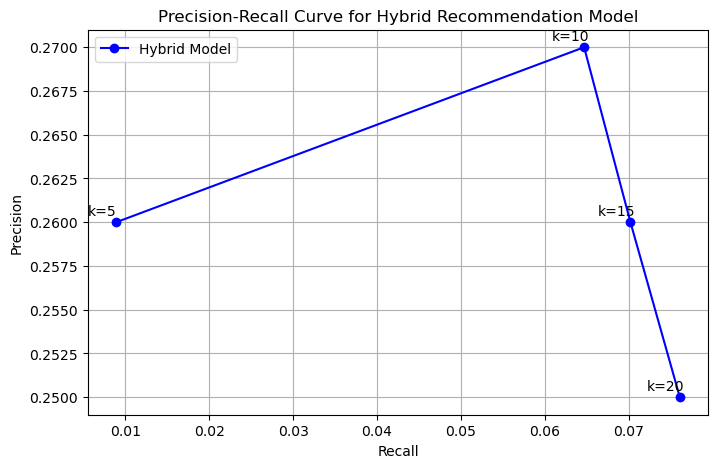

In [15]:
# Plot precision-recall curve
plt.figure(figsize=(8, 5))
plt.plot(hybrid_recall_scores, hybrid_precision_scores, marker='o', linestyle='-', color='b', label="Hybrid Model")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Hybrid Recommendation Model")
plt.grid(True)
for i, k in enumerate(k_values):
    plt.annotate(f"k={k}", (hybrid_recall_scores[i], hybrid_precision_scores[i]), textcoords="offset points", xytext=(-10,5), ha='center')
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_hybrid_rmse_updated(test_users, alpha=0.5, num_predictions=10):
    actual_ratings = []
    predicted_ratings = []

    for user_id in test_users:
        user_ratings = ratings_df[ratings_df['userId'] == user_id]

        for _, row in user_ratings.iterrows():
            movie_id = row['movieId']
            actual_rating = row['rating']

            # Collaborative prediction using KNN model
            try:
                collab_pred = knn.predict(user_id, movie_id).est
            except:
                continue  # Skip if prediction not possible

            # Content-based prediction using sigmoid similarity
            try:
                movie_index = movies_df[movies_df['movieId'] == movie_id].index[0]
                title = movies_df.loc[movie_index, 'title'].lower().strip()
                content_idx = indices.get(title)

                if content_idx is None:
                    continue  # Skip if movie is not in the content similarity matrix

                # Compute content-based predicted rating: average similarity-weighted rating
                sim_scores = sigmoid_sim[content_idx]
                top_indices = sim_scores.argsort()[-num_predictions:]
                
                similar_movies = movies_df.iloc[top_indices]
                ratings_subset = ratings_df[ratings_df['movieId'].isin(similar_movies['movieId'])]
                user_mean_rating = ratings_subset['rating'].mean() if not ratings_subset.empty else 3.0
                content_pred = user_mean_rating
            except:
                continue

            # Combine both predictions
            hybrid_pred = alpha * content_pred + (1 - alpha) * collab_pred

            predicted_ratings.append(hybrid_pred)
            actual_ratings.append(actual_rating)

    # Compute evaluation metrics
    mse = mean_squared_error(actual_ratings, predicted_ratings)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual_ratings, predicted_ratings)

    print(f"--- Hybrid Evaluation ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}\n")

    return mse, rmse


--- Hybrid Evaluation ---
MAE: 0.4899
MSE: 0.4307
RMSE: 0.6563

--- Hybrid Evaluation ---
MAE: 0.5227
MSE: 0.4676
RMSE: 0.6838

--- Hybrid Evaluation ---
MAE: 0.5671
MSE: 0.5298
RMSE: 0.7279

--- Hybrid Evaluation ---
MAE: 0.6241
MSE: 0.6173
RMSE: 0.7857

--- Hybrid Evaluation ---
MAE: 0.6870
MSE: 0.7301
RMSE: 0.8544



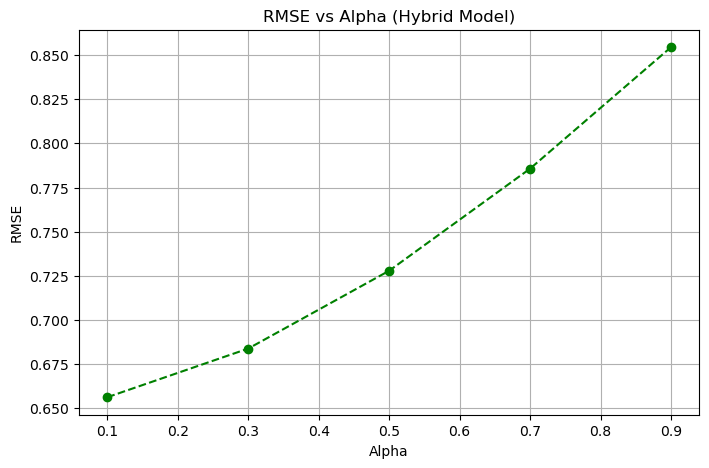

In [17]:
# Set random seed for reproducibility
np.random.seed(42)

# Random sample of test users
test_users = np.random.choice(ratings_df['userId'].unique(), size=10, replace=False)

# Evaluate across different alpha values
alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]
rmse_scores = []

for alpha in alpha_values:
    _, rmse = evaluate_hybrid_rmse_updated(test_users, alpha=alpha)
    rmse_scores.append(rmse)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(alpha_values, rmse_scores, marker='o', color='green', linestyle='--')
plt.title("RMSE vs Alpha (Hybrid Model)")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()
